# Sentiment-Analysis-Social-Media

### Import Libraries

In [91]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

### Current folder

In [92]:
import os
print(os.getcwd())

C:\Users\Rajamani


### Data

In [93]:
df = pd.read_csv(r"C:\Users\Rajamani\Downloads\twitter_sentiment_analysis.csv.zip", header=None)

print(df.head())

      0            1         2  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                   3  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [94]:
print(df.columns)
print(df.head())

Index([0, 1, 2, 3], dtype='int64')
      0            1         2  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                   3  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [95]:
df = pd.read_csv(r"C:\Users\Rajamani\Downloads\twitter_sentiment_analysis.csv.zip", header=None)
df.columns = ['ID', 'Topic', 'Sentiment', 'Text']

In [96]:
print(df.columns)

Index(['ID', 'Topic', 'Sentiment', 'Text'], dtype='object')


### Text Preprocessing

In [112]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

df['Text'] = df['Text'].apply(clean_text)

### Convert Text to Numbers

In [98]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['Text'])

y = df['Sentiment']

### Split Dataset

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Train Model

In [100]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [101]:
predictions = model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.7712392046595702


### Detailed Metrics

In [102]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

  Irrelevant       0.81      0.65      0.72      2592
    Negative       0.79      0.84      0.81      4519
     Neutral       0.73      0.75      0.74      3596
    Positive       0.77      0.80      0.78      4230

    accuracy                           0.77     14937
   macro avg       0.77      0.76      0.76     14937
weighted avg       0.77      0.77      0.77     14937



### Sentiment Distribution Graph

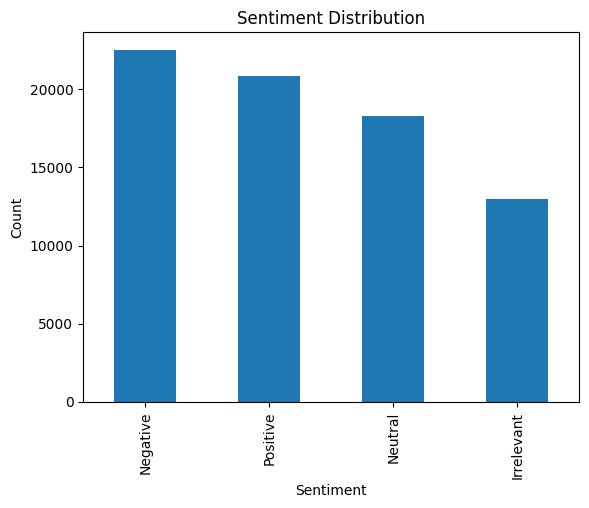

In [104]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

### Test Custom Sentences

In [105]:
sample_text = ["I really love this product"]

sample_vector = vectorizer.transform(sample_text)

result = model.predict(sample_vector)

print("Predicted Sentiment:", result[0])

Predicted Sentiment: Positive


### Predict Sentiment

In [106]:
predictions = model.predict(X_test)

### Evaluate Model

In [107]:
print("Accuracy:",
      accuracy_score(y_test, predictions))

print(classification_report(
      y_test,
      predictions))

Accuracy: 0.7712392046595702
              precision    recall  f1-score   support

  Irrelevant       0.81      0.65      0.72      2592
    Negative       0.79      0.84      0.81      4519
     Neutral       0.73      0.75      0.74      3596
    Positive       0.77      0.80      0.78      4230

    accuracy                           0.77     14937
   macro avg       0.77      0.76      0.76     14937
weighted avg       0.77      0.77      0.77     14937



In [108]:
text = ["This product is amazing"]

text_vector = vectorizer.transform(text)

prediction = model.predict(text_vector)

print(prediction)

['Positive']


### Sentiment Chart

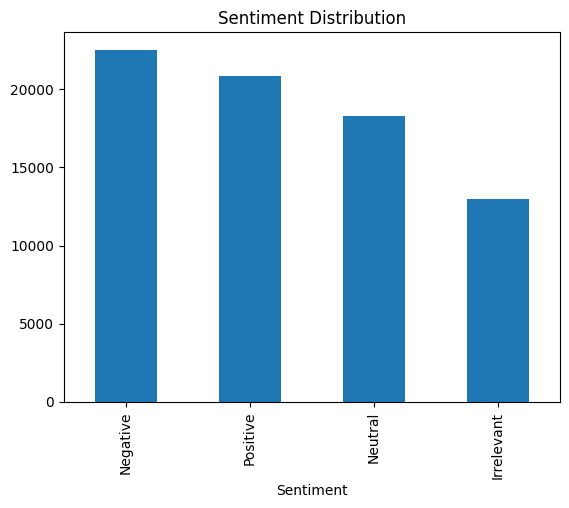

In [109]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")

plt.show()

### Classification Report

In [110]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

  Irrelevant       0.81      0.65      0.72      2592
    Negative       0.79      0.84      0.81      4519
     Neutral       0.73      0.75      0.74      3596
    Positive       0.77      0.80      0.78      4230

    accuracy                           0.77     14937
   macro avg       0.77      0.76      0.76     14937
weighted avg       0.77      0.77      0.77     14937



### Test Custom Sentences

In [111]:
sample_texts = [
    "I love this game",
    "This product is terrible",
    "The update is okay"
]

for text in sample_texts:
    vector = vectorizer.transform([text])
    prediction = model.predict(vector)
    print(f"{text} --> {prediction[0]}")

I love this game --> Positive
This product is terrible --> Negative
The update is okay --> Negative
